# Incident Reports Pipeline (End-to-End)

This notebook implements seven analytics phases for `datasets/incident_reports.csv`:
1. Problem Framing
2. Data Acquisition and Preparation
3. Exploration
4. Modeling (Explanatory + Predictive)
5. Evaluation and Selection
6. Feature Selection
7. Deployment

Target variable used: `follow_up_required` (classification).

## Modeling Goals (Required)
- **Predictive goal:** Build an out-of-sample model to support operational decisions for this pipeline.
- **Explanatory goal:** Build an interpretable model to explain the key relationships and likely drivers behind the target outcome.
- **Decision note:** Predictive performance does not establish causality; explanatory insights are reported with causal caveats.
- **Pipeline:** Incident Escalation Prediction


In [10]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [11]:
# Phase 1: Problem Framing

problem_framing = {
    'business_question': (
        'Which incident patterns are most associated with requiring follow-up, '
        'and how can we predict future follow-up needs earlier?'
    ),
    'target_variable': 'follow_up_required',
    'predictive_goal': (
        'Predict whether a newly recorded incident is likely to require follow-up '
        'so teams can prioritize interventions.'
    ),
    'explanatory_goal': (
        'Quantify which incident characteristics are associated with follow-up risk '
        'to guide policy and staffing decisions.'
    ),
    'success_metrics': {
        'predictive': ['ROC-AUC (higher is better)', 'F1 (higher is better)', 'Recall (higher is better)'],
        'explanatory': ['Coefficient direction and relative magnitude', 'Business plausibility']
    }
}

problem_framing

{'business_question': 'Which incident patterns are most associated with requiring follow-up, and how can we predict future follow-up needs earlier?',
 'target_variable': 'follow_up_required',
 'predictive_goal': 'Predict whether a newly recorded incident is likely to require follow-up so teams can prioritize interventions.',
 'explanatory_goal': 'Quantify which incident characteristics are associated with follow-up risk to guide policy and staffing decisions.',
 'success_metrics': {'predictive': ['ROC-AUC (higher is better)',
   'F1 (higher is better)',
   'Recall (higher is better)'],
  'explanatory': ['Coefficient direction and relative magnitude',
   'Business plausibility']}}

In [12]:
# Phase 2: Data Acquisition and Preparation

csv_path = '../datasets/incident_reports.csv'
raw_df = pd.read_csv(csv_path)
df = raw_df.copy()

# Parse and standardize types
for col in ['incident_id', 'resident_id', 'safehouse_id']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['incident_date', 'resolution_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

categorical_cols = ['incident_type', 'severity', 'description', 'response_taken', 'reported_by']
for col in categorical_cols:
    df[col] = df[col].astype('string').str.strip()

# Normalize booleans
for col in ['resolved', 'follow_up_required']:
    df[col] = df[col].astype(str).str.lower().map({'true': 1, 'false': 0})

# Feature engineering
reference_date = df['incident_date'].max()
df['days_since_incident'] = (reference_date - df['incident_date']).dt.days
df['resolution_time_days'] = (df['resolution_date'] - df['incident_date']).dt.days
df['has_resolution_date'] = df['resolution_date'].notna().astype(int)

# Data quality snapshot
data_quality = {
    'rows': int(len(df)),
    'columns': int(len(df.columns)),
    'missing_values_total': int(df.isna().sum().sum()),
    'target_distribution': df['follow_up_required'].value_counts(dropna=False).to_dict(),
}

print(data_quality)
df.head()

{'rows': 100, 'columns': 15, 'missing_values_total': 58, 'target_distribution': {0: 58, 1: 42}}


,incident_id,resident_id,safehouse_id,incident_date,incident_type,severity,description,response_taken,resolved,resolution_date,reported_by,follow_up_required,days_since_incident,resolution_time_days,has_resolution_date
0,1,1,4,2024-06-22,Medical,Medium,Medical incident reported on 2024-06-22,Response to medical,1,2024-07-01,SW-19,0,656,9.0,1
1,2,1,4,2026-02-10,Security,High,Security incident reported on 2026-02-10,Response to security,0,NaT,SW-20,1,58,NaN,0
2,3,1,4,2024-02-03,RunawayAttempt,Low,RunawayAttempt incident reported on 2024-02-03,Response to runawayattempt,1,2024-02-10,SW-18,0,796,7.0,1
3,4,1,4,2025-04-17,Behavioral,Low,Behavioral incident reported on 2025-04-17,Response to behavioral,1,2025-04-23,SW-12,0,357,6.0,1
4,5,3,1,2025-05-12,SelfHarm,High,SelfHarm incident reported on 2025-05-12,Response to selfharm,0,NaT,SW-08,1,332,NaN,0


In [13]:
# Reproducible preprocessing definitions

target_col = 'follow_up_required'
feature_cols = [
    'resident_id',
    'safehouse_id',
    'incident_type',
    'severity',
    'resolved',
    'reported_by',
    'days_since_incident',
    'resolution_time_days',
    'has_resolution_date',
]

model_df = df[feature_cols + [target_col]].copy()
X = model_df[feature_cols]
y = model_df[target_col].astype(int)

numeric_features = ['resident_id', 'safehouse_id', 'resolved', 'days_since_incident', 'resolution_time_days', 'has_resolution_date']
categorical_features = ['incident_type', 'severity', 'reported_by']

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train rows: {len(X_train)} | Test rows: {len(X_test)}')

Train rows: 80 | Test rows: 20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   incident_id           100 non-null    int64         
 1   resident_id           100 non-null    int64         
 2   safehouse_id          100 non-null    int64         
 3   incident_date         100 non-null    datetime64[ns]
 4   incident_type         100 non-null    string        
 5   severity              100 non-null    string        
 6   description           100 non-null    string        
 7   response_taken        100 non-null    string        
 8   resolved              100 non-null    int64         
 9   resolution_date       71 non-null     datetime64[ns]
 10  reported_by           100 non-null    string        
 11  follow_up_required    100 non-null    int64         
 12  days_since_incident   100 non-null    int64         
 13  resolution_time_days 

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
incident_id,100.0,NaN,NaN,NaN,50.5,1.0,25.75,50.5,75.25,100.0,29.011492
resident_id,100.0,NaN,NaN,NaN,28.83,1.0,14.0,26.0,44.0,59.0,17.534413
safehouse_id,100.0,NaN,NaN,NaN,4.32,1.0,2.0,4.0,6.0,9.0,2.534131
incident_date,100,NaN,NaN,NaN,2024-12-31 06:28:48,2023-04-08 00:00:00,2024-06-20 18:00:00,2025-01-27 12:00:00,2025-08-14 00:00:00,2026-04-09 00:00:00,NaN
incident_type,100,7,RunawayAttempt,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
severity,100,3,Medium,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,100,100,Medical incident reported on 2024-06-22,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
response_taken,100,7,Response to runawayattempt,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolved,100.0,NaN,NaN,NaN,0.71,0.0,0.0,1.0,1.0,1.0,0.456048
resolution_date,71,NaN,NaN,NaN,2025-01-12 00:00:00,2023-10-04 00:00:00,2024-05-22 00:00:00,2025-02-22 00:00:00,2025-09-07 12:00:00,2026-04-17 00:00:00,NaN


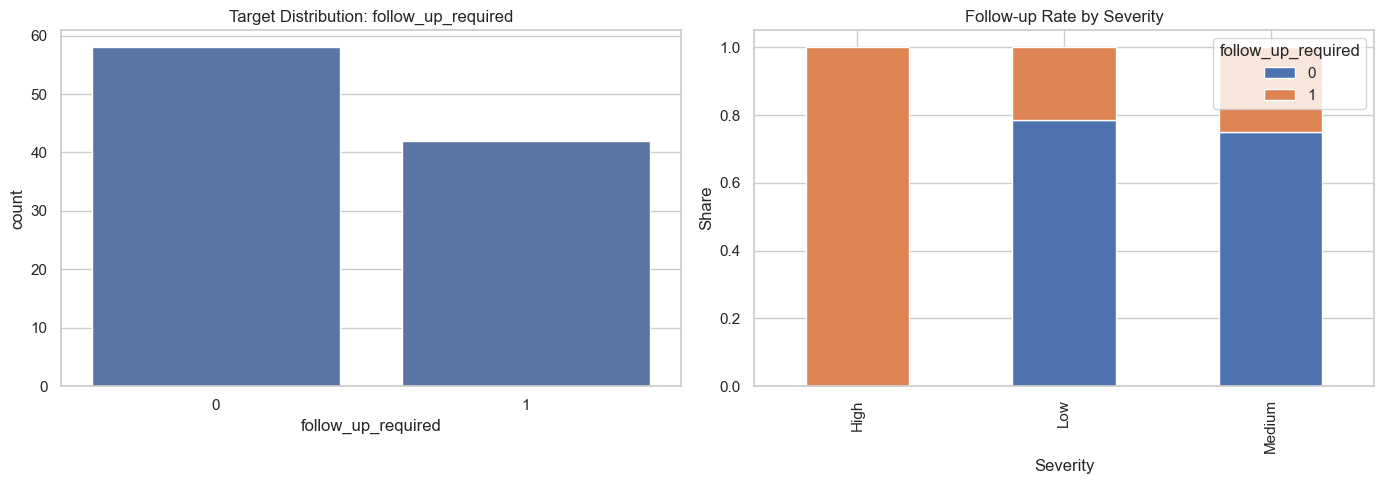

follow_up_required,0,1
incident_type,,
RunawayAttempt,0.413793,0.586207
SelfHarm,0.428571,0.571429
Security,0.500000,0.500000
ConflictWithPeer,0.545455,0.454545
Behavioral,0.800000,0.200000
Medical,1.000000,0.000000
PropertyDamage,1.000000,0.000000


In [14]:
# Phase 3: Exploration

df.info()
display(df.describe(include='all').T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='follow_up_required', ax=axes[0])
axes[0].set_title('Target Distribution: follow_up_required')
axes[0].set_xlabel('follow_up_required')

severity_followup = pd.crosstab(df['severity'], df['follow_up_required'], normalize='index')
severity_followup.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Follow-up Rate by Severity')
axes[1].set_xlabel('Severity')
axes[1].set_ylabel('Share')
axes[1].legend(title='follow_up_required')

plt.tight_layout()
plt.show()

incident_followup_summary = pd.crosstab(df['incident_type'], df['follow_up_required'], normalize='index')
incident_followup_summary.sort_values(by=1, ascending=False).head(10)

In [15]:
# Phase 4: Modeling (Explanatory + Predictive)

# Explanatory model: Logistic Regression
explanatory_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ]
)

# Predictive model: Random Forest
predictive_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            class_weight='balanced_subsample',
            min_samples_leaf=2,
        )),
    ]
)

explanatory_model.fit(X_train, y_train)
predictive_model.fit(X_train, y_train)

print('Models trained successfully.')

Models trained successfully.


,model,accuracy,precision,recall,f1,roc_auc
1,random_forest,1.00,1.0,1.000,1.000000,1.0
0,logistic_regression,0.95,1.0,0.875,0.933333,1.0


Selected model: random_forest

Classification report (best model):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



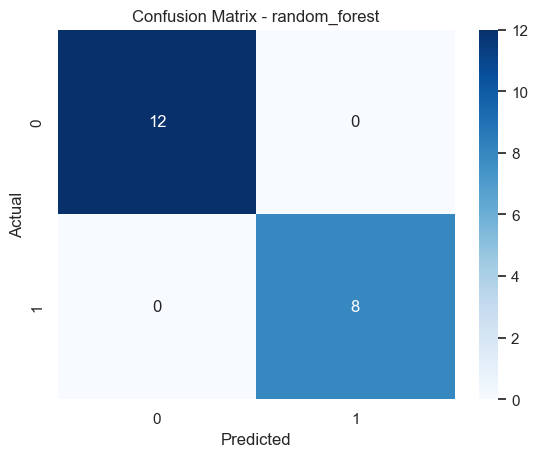

In [16]:
# Phase 5: Evaluation and Selection

def evaluate_classifier(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = None

    results = {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
    }
    if y_prob is not None and y_eval.nunique() > 1:
        results['roc_auc'] = roc_auc_score(y_eval, y_prob)
    else:
        results['roc_auc'] = np.nan

    return results, y_pred

exp_metrics, exp_pred = evaluate_classifier('logistic_regression', explanatory_model, X_test, y_test)
prd_metrics, prd_pred = evaluate_classifier('random_forest', predictive_model, X_test, y_test)

metrics_df = pd.DataFrame([exp_metrics, prd_metrics]).sort_values(by='f1', ascending=False)
display(metrics_df)

best_model_name = metrics_df.iloc[0]['model']
best_model = predictive_model if best_model_name == 'random_forest' else explanatory_model
print(f'Selected model: {best_model_name}')

print('\nClassification report (best model):')
print(classification_report(y_test, best_model.predict(X_test), zero_division=0))

cm = confusion_matrix(y_test, best_model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [17]:
# Cross-validation check on selected model

cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='f1',
)

print(f'CV F1 mean: {cv_scores.mean():.3f}')
print(f'CV F1 std:  {cv_scores.std():.3f}')

CV F1 mean: 1.000
CV F1 std:  0.000


,feature,importance_mean,importance_std
0,severity,0.390381,0.097237
1,has_resolution_date,0.026471,0.029264
2,resident_id,0.000000,0.000000
3,safehouse_id,0.000000,0.000000
4,incident_type,0.000000,0.000000
5,resolved,0.000000,0.000000
6,reported_by,0.000000,0.000000
7,days_since_incident,0.000000,0.000000
8,resolution_time_days,0.000000,0.000000


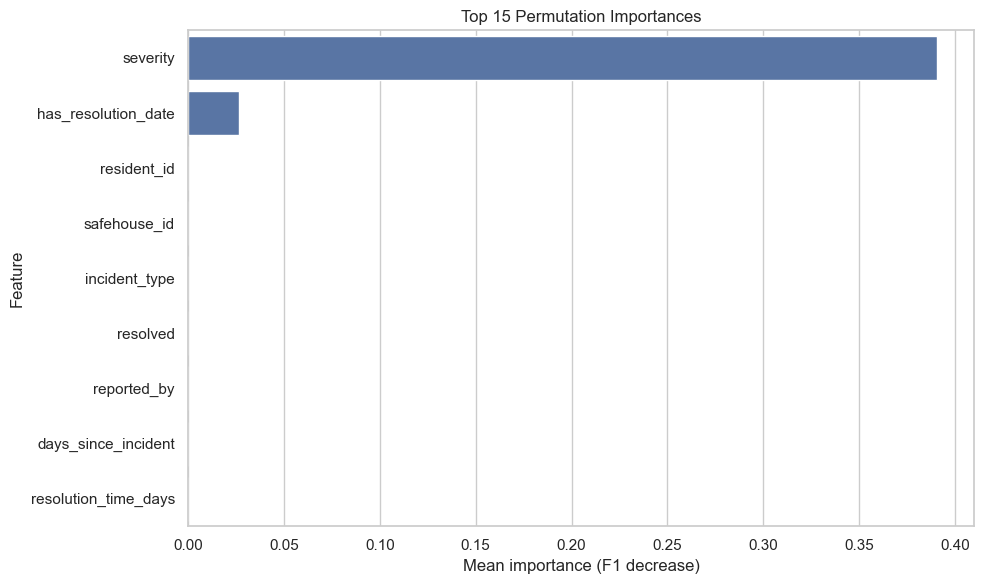

In [18]:
# Phase 6: Feature Selection / Importance

# For a full sklearn Pipeline, permutation importance is reported at the
# original input-column level (not one-hot-expanded transformed columns).
input_feature_names = X_test.columns

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring='f1',
    n_repeats=20,
    random_state=42,
)

importance_df = pd.DataFrame({
    'feature': input_feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values(by='importance_mean', ascending=False)

top_features = importance_df.head(15).reset_index(drop=True)
display(top_features)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, y='feature', x='importance_mean', orient='h')
plt.title('Top 15 Permutation Importances')
plt.xlabel('Mean importance (F1 decrease)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [19]:
# Phase 7: Deployment / Artifact Export

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / 'incident_reports_predictive_model.joblib'
schema_path = artifacts_dir / 'incident_reports_model_schema.json'
features_path = artifacts_dir / 'incident_reports_top_features.csv'
prepared_path = artifacts_dir / 'incident_reports_prepared.csv'
fairness_path = artifacts_dir / 'incident_reports_fairness_report.csv'

joblib.dump(best_model, model_path)
top_features.to_csv(features_path, index=False)
model_df.to_csv(prepared_path, index=False)

schema = {
    'target': target_col,
    'feature_columns': feature_cols,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'selected_model': best_model_name,
    'metrics': metrics_df.to_dict(orient='records'),
}

with open(schema_path, 'w', encoding='utf-8') as f:
    json.dump(schema, f, indent=2)

# Simple group fairness view by severity: predicted positive rate and actual rate
fairness_df = X_test.copy()
fairness_df['actual'] = y_test.values
fairness_df['predicted'] = best_model.predict(X_test)

severity_fairness = fairness_df.groupby('severity').agg(
    actual_positive_rate=('actual', 'mean'),
    predicted_positive_rate=('predicted', 'mean'),
    support=('actual', 'size'),
).reset_index()
severity_fairness.to_csv(fairness_path, index=False)

{
    'model_path': str(model_path),
    'schema_path': str(schema_path),
    'top_features_path': str(features_path),
    'prepared_data_path': str(prepared_path),
    'fairness_report_path': str(fairness_path),
}

{'model_path': 'artifacts\\incident_reports_predictive_model.joblib',
 'schema_path': 'artifacts\\incident_reports_model_schema.json',
 'top_features_path': 'artifacts\\incident_reports_top_features.csv',
 'prepared_data_path': 'artifacts\\incident_reports_prepared.csv',
 'fairness_report_path': 'artifacts\\incident_reports_fairness_report.csv'}

In [20]:
# Optional: explanatory coefficients for Logistic Regression

# Refit explanatory model on all data for cleaner interpretation
explanatory_model.fit(X, y)

exp_preprocessor = explanatory_model.named_steps['preprocessor']
exp_feature_names = exp_preprocessor.get_feature_names_out()
exp_coefs = explanatory_model.named_steps['model'].coef_.ravel()

coef_df = pd.DataFrame({
    'feature': exp_feature_names,
    'coefficient': exp_coefs,
}).sort_values(by='coefficient', key=np.abs, ascending=False)

coef_df.head(20)

,feature,coefficient
13,cat__severity_High,2.556984
15,cat__severity_Medium,-1.384005
2,num__resolved,-1.365376
5,num__has_resolution_date,-1.365376
14,cat__severity_Low,-1.172525
23,cat__reported_by_SW-08,0.363063
0,num__resident_id,-0.327369
12,cat__incident_type_SelfHarm,0.308274
10,cat__incident_type_RunawayAttempt,0.306005
35,cat__reported_by_SW-20,0.281712


## Deployment Notes (Web App Integration)
- **Primary endpoint:** `/api/admin/analytics/ml-pipeline-summaries`
- **UI surface:** `frontend/src/pages/AdminAnalytics.tsx`
- **Artifact contract:** `ml-pipelines/artifacts/{pipeline}_model_metrics.csv`, `{pipeline}_top_features.csv`, `{pipeline}_model_schema.json`
- **Top-3 fully integrated:** `residents`, `donation_allocations`, `safehouses`
- **Remaining pipelines:** deployment-ready through the same artifact contract and endpoint expansion.
